# Member 1 — Regression EDA, Cleaning, Preprocessing, Feature Engineering

Dataset: `data/airquality/AirQualityUCI.csv` (UCI Air Quality). Target: `CO(GT)`.
Scope: dataset audit, distribution/correlation/scatter plots, missing-value + outlier
cleaning, stratified train/test split, median imputation + IQR capping (fit on train only),
`T_RH_Interaction` engineered feature, scaling. Output feeds Member 2's regression models
via `data/processed/regression_train.csv` / `regression_test.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/raw/airquality/AirQualityUCI.csv",
    sep=";",
    decimal=","
)

print("Dataset loaded successfully.")

# Raw CSV ships 114 fully-empty trailing rows (an artifact of the export, not real
# missing data) — drop them before any audit so missingness stats aren't inflated.
df = df.dropna(how="all")
print("Shape after dropping fully-empty trailing rows:", df.shape)

Dataset loaded successfully.
Shape after dropping fully-empty trailing rows: (9357, 17)


In [2]:
# Convert only measurement columns to numeric

measurement_cols = df.columns[2:]

for col in measurement_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)

Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object


In [3]:
# Dataset Audit

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (9357, 17)

Column Names:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']

Data Types:
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object

Missing Values:
Date                0
Time                0
CO(GT)              0
PT08.S1(CO)         0
NMHC(GT)            0
C6H6(GT)            0
PT08.S2(NMHC)       0
NOx(GT)             0
PT08.S3(NOx)        0
NO2(GT)             0
PT08.S4(NO2)        0
PT08.S5(O3)         0
T                   0
RH   

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,NaN,NaN


In [4]:
# Remove unnecessary columns

df = df.drop(columns=["Unnamed: 15", "Unnamed: 16"])

# Replace -200 with NaN
df = df.replace(-200, np.nan)

print("Shape after removing unnecessary columns:", df.shape)

print("\nMissing Values after replacing -200:")
print(df.isnull().sum())

Shape after removing unnecessary columns: (9357, 15)

Missing Values after replacing -200:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [5]:
# Parse Date/Time and engineer hour/day/month features
# Date is DD/MM/YYYY, Time uses dots as separators (HH.MM.SS) instead of colons
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'].str.replace('.', ':', regex=False),
    format='%d/%m/%Y %H:%M:%S'
)
df['hour'] = df['Datetime'].dt.hour
df['day'] = df['Datetime'].dt.day
df['month'] = df['Datetime'].dt.month

print(df[['Date', 'Time', 'hour', 'day', 'month']].head())

         Date      Time  hour  day  month
0  10/03/2004  18.00.00    18   10      3
1  10/03/2004  19.00.00    19   10      3
2  10/03/2004  20.00.00    20   10      3
3  10/03/2004  21.00.00    21   10      3
4  10/03/2004  22.00.00    22   10      3


In [6]:
# Drop raw Date/Time/Datetime (already captured as hour/day/month) and the
# highly-missing NMHC(GT) column

df = df.drop(columns=["Date", "Time", "Datetime", "NMHC(GT)"])

print("Shape after removing unusable columns:", df.shape)

print("\nRemaining Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Shape after removing unusable columns: (9357, 15)

Remaining Columns:
['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'hour', 'day', 'month']

Missing Values:
CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
hour                0
day                 0
month               0
dtype: int64


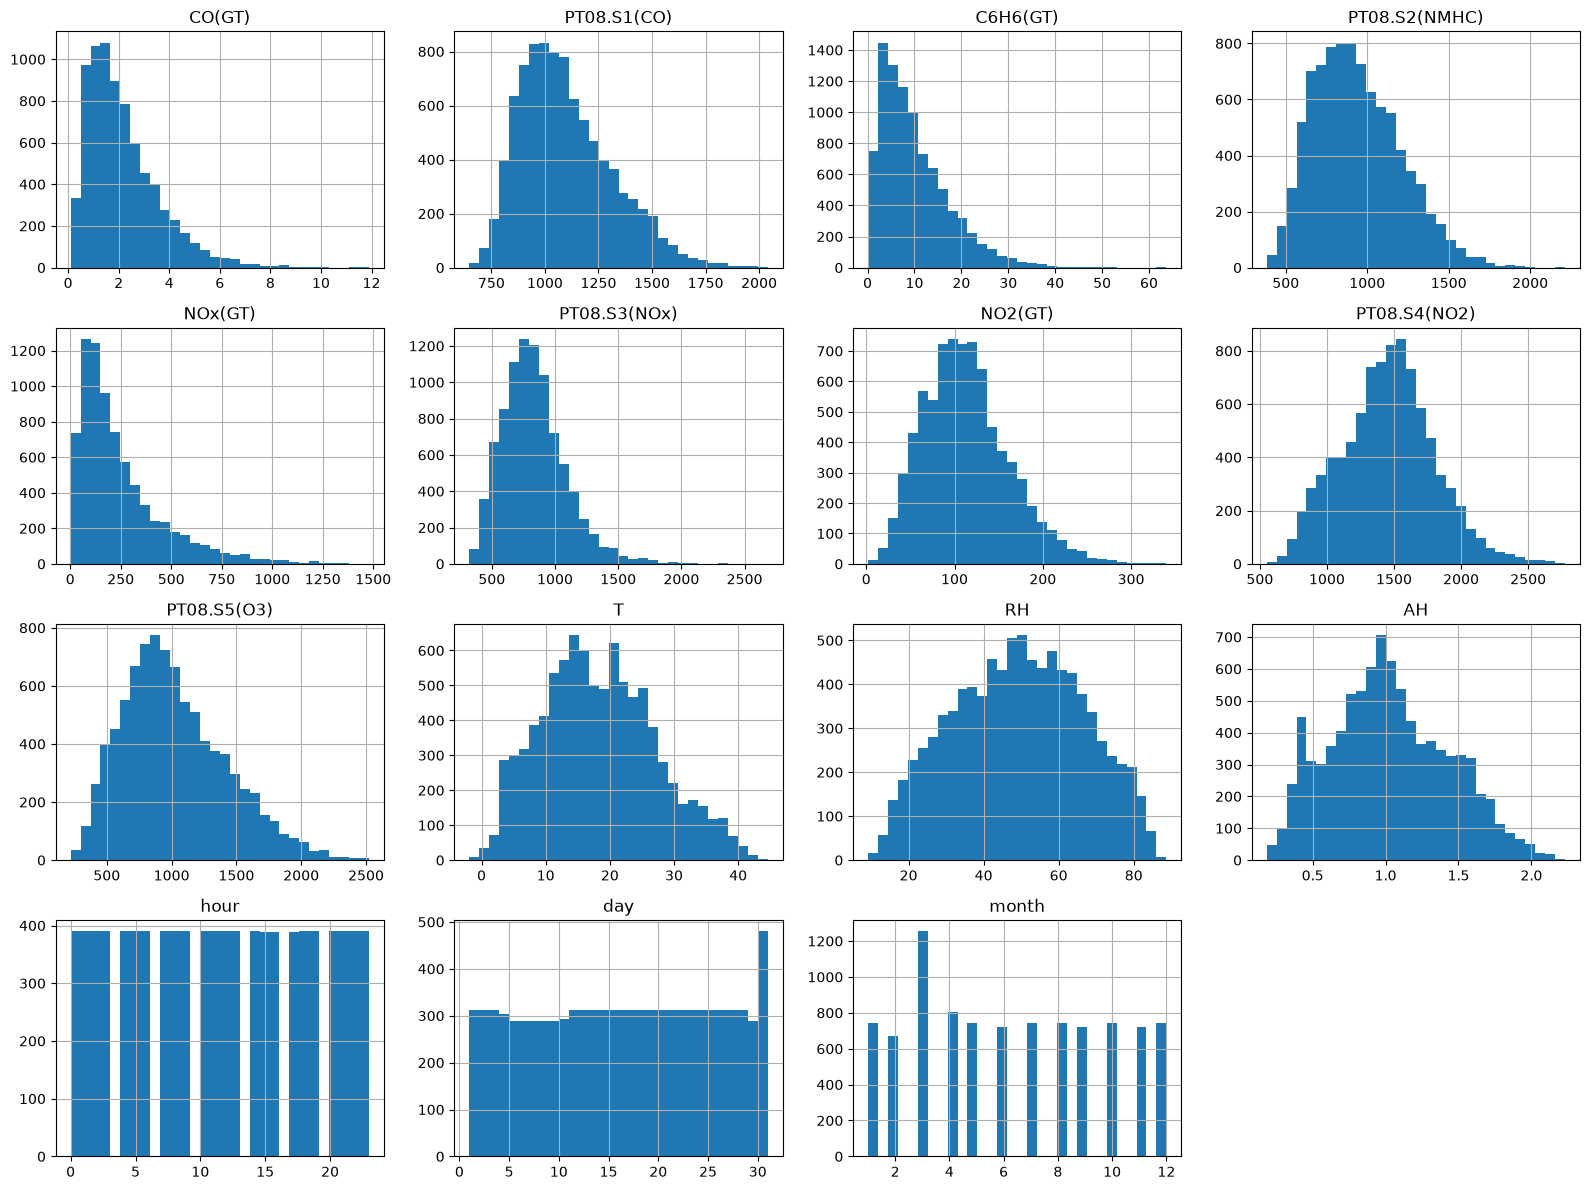

In [7]:
# Distribution plots

df.hist(figsize=(16, 12), bins=30)

plt.tight_layout()
plt.show()

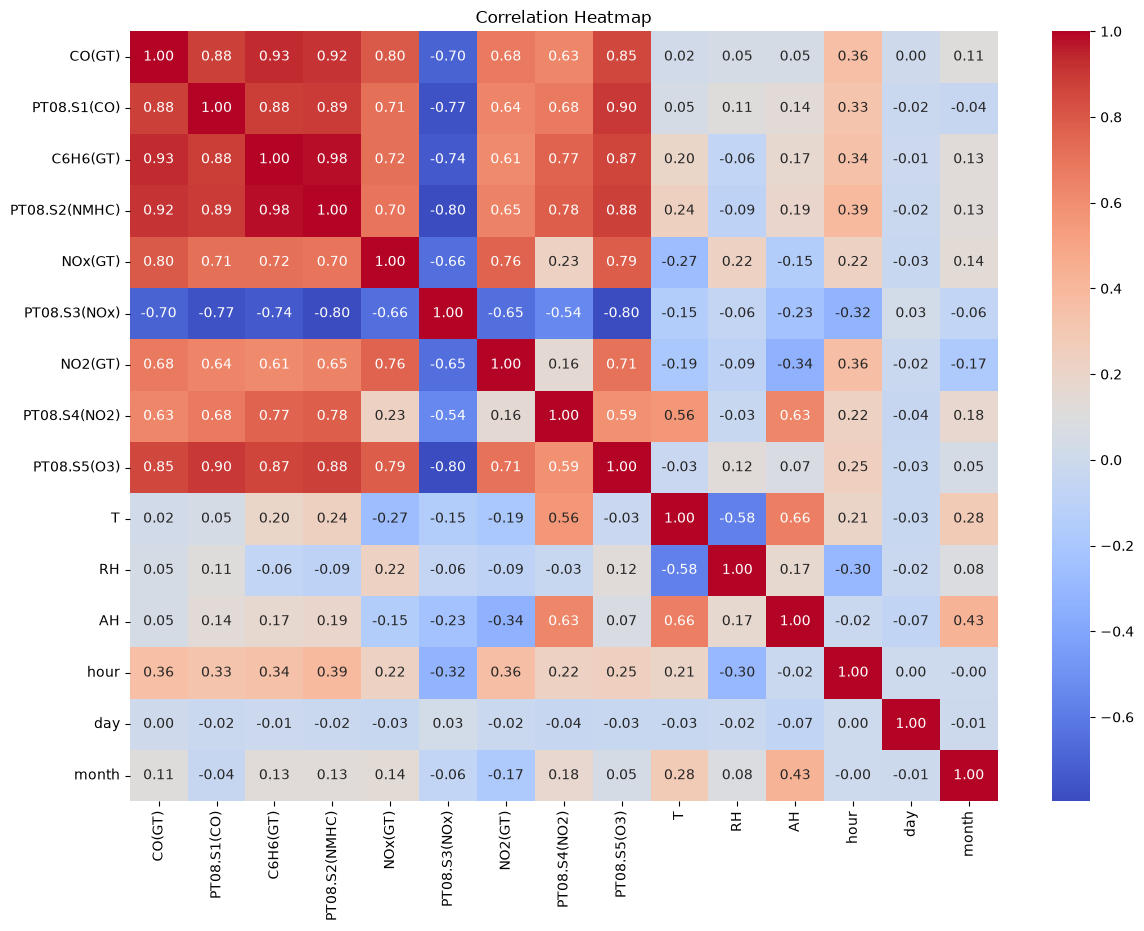

In [8]:
# Correlation Heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

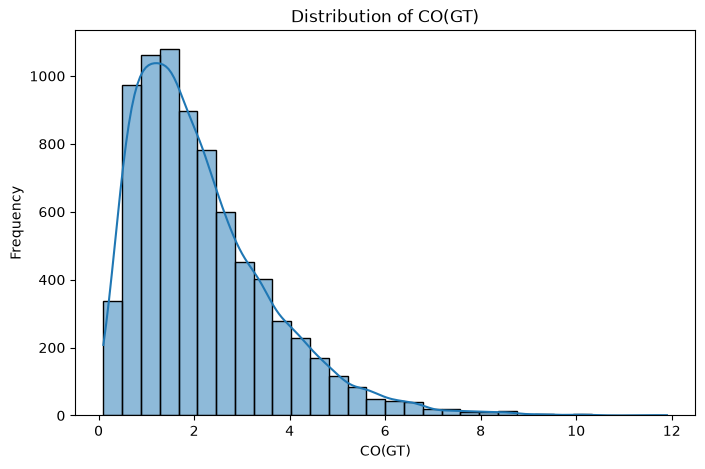

In [9]:
# Target Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    df["CO(GT)"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of CO(GT)")
plt.xlabel("CO(GT)")
plt.ylabel("Frequency")

plt.show()

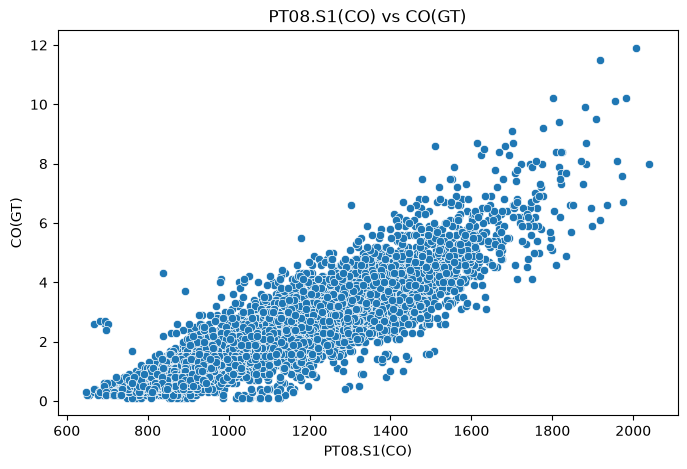

In [10]:
# Scatter Plot 1

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="PT08.S1(CO)",
    y="CO(GT)"
)

plt.title("PT08.S1(CO) vs CO(GT)")
plt.xlabel("PT08.S1(CO)")
plt.ylabel("CO(GT)")

plt.show()

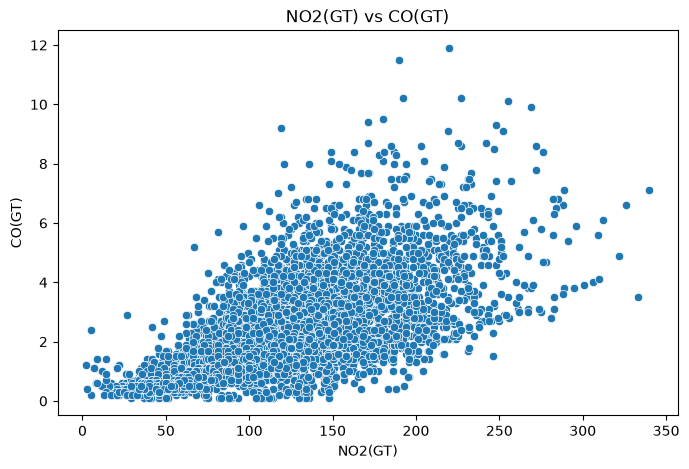

In [11]:
# Scatter Plot 2

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="NO2(GT)",
    y="CO(GT)"
)

plt.title("NO2(GT) vs CO(GT)")
plt.xlabel("NO2(GT)")
plt.ylabel("CO(GT)")

plt.show()

## EDA Insights

### Distribution Plots
- Most pollutant and sensor variables show non-normal distributions with noticeable skewness.
- Several variables have longer right tails, indicating the presence of relatively high pollutant or sensor measurements.

### Correlation Heatmap
- `CO(GT)` shows strong positive correlations with several variables, including `C6H6(GT)` (0.93), `PT08.S2(NMHC)` (0.92), `PT08.S1(CO)` (0.88), and `PT08.S5(O3)` (0.85).
- `CO(GT)` has a negative correlation with `PT08.S3(NOx)` (-0.70).
- The high correlations among several sensor variables indicate that some features contain related information.

### Target Distribution
- The `CO(GT)` target distribution is positively skewed, with most observations concentrated at lower CO values and a smaller number of observations extending toward higher values.

### Scatter Plot Observations
- `PT08.S1(CO)` vs `CO(GT)` shows a clear positive relationship. Higher `PT08.S1(CO)` values are generally associated with higher `CO(GT)` values.
- `NO2(GT)` vs `CO(GT)` also shows a positive relationship, although the observations are more dispersed than in the `PT08.S1(CO)` plot.
- These relationships suggest that these variables may contain useful information for predicting `CO(GT)`.

In [12]:
# Missing Value Analysis

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent.round(2)
})

display(missing_table)

,Missing Count,Missing Percentage
CO(GT),1683,17.99
PT08.S1(CO),366,3.91
C6H6(GT),366,3.91
PT08.S2(NMHC),366,3.91
NOx(GT),1639,17.52
PT08.S3(NOx),366,3.91
NO2(GT),1642,17.55
PT08.S4(NO2),366,3.91
PT08.S5(O3),366,3.91
T,366,3.91


In [13]:
# Duplicate Row Check

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
# Outlier Analysis using IQR method

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = ((df < lower_bound) | (df > upper_bound)).sum()

outlier_table = pd.DataFrame({
    "Outlier Count": outlier_count,
    "Outlier Percentage": (outlier_count / len(df) * 100).round(2)
})

display(outlier_table)

,Outlier Count,Outlier Percentage
CO(GT),215,2.30
PT08.S1(CO),118,1.26
C6H6(GT),228,2.44
PT08.S2(NMHC),65,0.69
NOx(GT),435,4.65
PT08.S3(NOx),241,2.58
NO2(GT),107,1.14
PT08.S4(NO2),97,1.04
PT08.S5(O3),93,0.99
T,3,0.03


In [15]:
# Remove rows where the target is missing

df = df.dropna(subset=["CO(GT)"])

print("Shape after removing missing target rows:", df.shape)
print("\nMissing values remaining:")
print(df.isnull().sum())

Shape after removing missing target rows: (7674, 15)

Missing values remaining:
CO(GT)             0
PT08.S1(CO)      330
C6H6(GT)         330
PT08.S2(NMHC)    330
NOx(GT)          413
PT08.S3(NOx)     330
NO2(GT)          416
PT08.S4(NO2)     330
PT08.S5(O3)      330
T                330
RH               330
AH               330
hour               0
day                0
month              0
dtype: int64


In [16]:
# Final Duplicate Check

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [17]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

Shape after removing duplicates: (7674, 15)
Duplicate rows remaining: 0


In [18]:
from sklearn.model_selection import train_test_split

# Separate features and target

X = df.drop(columns=["CO(GT)"])
y = df["CO(GT)"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7674, 14)
Target shape: (7674,)


In [19]:
from sklearn.model_selection import train_test_split

# Create bins from the continuous target for stratification
y_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

# Stratified 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6139, 14)
X_test shape: (1535, 14)
y_train shape: (6139,)
y_test shape: (1535,)


In [20]:
from sklearn.impute import SimpleImputer

# Create median imputer
imputer = SimpleImputer(strategy="median")

# Fit only on training data
X_train_imputed = imputer.fit_transform(X_train)

# Apply the same imputer to test data
X_test_imputed = imputer.transform(X_test)

print("Missing values in X_train after imputation:",
      np.isnan(X_train_imputed).sum())

print("Missing values in X_test after imputation:",
      np.isnan(X_test_imputed).sum())

Missing values in X_train after imputation: 0
Missing values in X_test after imputation: 0


In [21]:
# Convert imputed arrays back to DataFrames

X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=X_test.columns,
    index=X_test.index
)

print("X_train_imputed shape:", X_train_imputed.shape)
print("X_test_imputed shape:", X_test_imputed.shape)

X_train_imputed shape: (6139, 14)
X_test_imputed shape: (1535, 14)


In [22]:
# Calculate IQR bounds using training data only

Q1_train = X_train_imputed.quantile(0.25)
Q3_train = X_train_imputed.quantile(0.75)

IQR_train = Q3_train - Q1_train

lower_bound = Q1_train - 1.5 * IQR_train
upper_bound = Q3_train + 1.5 * IQR_train

print("IQR bounds calculated using training data only.")

IQR bounds calculated using training data only.


In [23]:
# Cap outliers using training-derived IQR bounds

X_train_capped = X_train_imputed.clip(
    lower=lower_bound,
    upper=upper_bound,
    axis="columns"
)

X_test_capped = X_test_imputed.clip(
    lower=lower_bound,
    upper=upper_bound,
    axis="columns"
)

print("Outlier capping completed.")
print("X_train_capped shape:", X_train_capped.shape)
print("X_test_capped shape:", X_test_capped.shape)

Outlier capping completed.
X_train_capped shape: (6139, 14)
X_test_capped shape: (1535, 14)


In [24]:
# Feature Engineering
# Create a temperature-humidity interaction feature

X_train_capped["T_RH_Interaction"] = (
    X_train_capped["T"] * X_train_capped["RH"]
)

X_test_capped["T_RH_Interaction"] = (
    X_test_capped["T"] * X_test_capped["RH"]
)

print("Feature engineering completed.")
print("\nNew feature added: T_RH_Interaction")

print("\nX_train shape:", X_train_capped.shape)
print("X_test shape:", X_test_capped.shape)

Feature engineering completed.

New feature added: T_RH_Interaction

X_train shape: (6139, 15)
X_test shape: (1535, 15)


### Feature Engineering

A new feature, `T_RH_Interaction`, was created by multiplying temperature (`T`) and relative humidity (`RH`). This feature represents the combined effect of these two meteorological conditions and may provide additional information for predicting the `CO(GT)` target beyond their individual values.

In [25]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train_capped)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test_capped)

print("Scaling completed.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling completed.
X_train_scaled shape: (6139, 15)
X_test_scaled shape: (1535, 15)


In [26]:
# Convert scaled arrays back to DataFrames

X_train_final = pd.DataFrame(
    X_train_scaled,
    columns=X_train_capped.columns,
    index=X_train_capped.index
)

X_test_final = pd.DataFrame(
    X_test_scaled,
    columns=X_test_capped.columns,
    index=X_test_capped.index
)

# Add target column
X_train_final["CO(GT)"] = y_train.loc[X_train_final.index]
X_test_final["CO(GT)"] = y_test.loc[X_test_final.index]

print("Final training data shape:", X_train_final.shape)
print("Final testing data shape:", X_test_final.shape)

Final training data shape: (6139, 16)
Final testing data shape: (1535, 16)


In [27]:
# Save final processed datasets

X_train_final.to_csv(
    "../data/processed/regression_train.csv",
    index=False
)

X_test_final.to_csv(
    "../data/processed/regression_test.csv",
    index=False
)

print("Files saved successfully!")
print("regression_train.csv")
print("regression_test.csv")

Files saved successfully!
regression_train.csv
regression_test.csv


In [28]:
# Final Verification

print("=== TRAINING DATA ===")
print("Shape:", X_train_final.shape)
print("Missing values:", X_train_final.isnull().sum().sum())

print("\n=== TESTING DATA ===")
print("Shape:", X_test_final.shape)
print("Missing values:", X_test_final.isnull().sum().sum())

print("\n=== COLUMN CHECK ===")
print("Columns match:", list(X_train_final.columns) == list(X_test_final.columns))

print("\n=== TARGET CHECK ===")
print("Target in train:", "CO(GT)" in X_train_final.columns)
print("Target in test:", "CO(GT)" in X_test_final.columns)

print("\n=== TRAIN FEATURE MEANS ===")
print(X_train_final.drop(columns=["CO(GT)"]).mean().round(3))

=== TRAINING DATA ===
Shape: (6139, 16)
Missing values: 0

=== TESTING DATA ===
Shape: (1535, 16)
Missing values: 0

=== COLUMN CHECK ===
Columns match: True

=== TARGET CHECK ===
Target in train: True
Target in test: True

=== TRAIN FEATURE MEANS ===
PT08.S1(CO)        -0.0
C6H6(GT)            0.0
PT08.S2(NMHC)      -0.0
NOx(GT)             0.0
PT08.S3(NOx)        0.0
NO2(GT)            -0.0
PT08.S4(NO2)        0.0
PT08.S5(O3)         0.0
T                  -0.0
RH                 -0.0
AH                 -0.0
hour                0.0
day                 0.0
month              -0.0
T_RH_Interaction   -0.0
dtype: float64


## Data Analysis, Cleaning and Preprocessing Summary

The Air Quality dataset was analyzed using dataset auditing, distribution plots, a correlation heatmap, target distribution, and scatter plots. The target variable selected for regression is `CO(GT)`.

During data cleaning, unnecessary columns were removed and the `-200` values representing missing measurements were converted to `NaN`. The highly missing `NMHC(GT)` feature was removed, and rows with missing `CO(GT)` target values were removed. Duplicate rows were checked and one duplicate was removed. Potential outliers were identified using the IQR method and feature values were capped using training-data-derived limits.

The data was divided into training and testing sets using an 80:20 stratified split with `random_state=42`. Remaining missing feature values were handled using median imputation fitted only on the training data.

A new feature, `T_RH_Interaction`, was created by multiplying temperature (`T`) and relative humidity (`RH`) to represent their combined effect. Finally, all input features were standardized using `StandardScaler`, fitted only on the training data and then applied to the test data.

The final processed datasets contain 12 input features and `CO(GT)` as the target, with no missing values and matching train/test columns.